# Ibrahim Khalid Al-Hamidy's Student Capstone Project in ML, Deep Learning & NLP Applications

#### For this Capstone, I'll be using the Fake News Dataset; "fake-and-real-news-dataset" by clmentbisaillon to be exact.

In [2]:
RANDOM_STATE = 42
#These are all the imports I'll be using
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Cleaning
import re
import string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Machine Learning
from sklearn.model_selection import train_test_split

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ibrah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
#Load both datasets
fake = pd.read_csv("datafolder/Fake.csv")
true = pd.read_csv("datafolder/True.csv")

In [4]:
#Add Labels
fake["label"] = 0
true["label"] = 1

In [5]:
#And now combine them
df = pd.concat([fake, true], ignore_index=True)

In [6]:
#Now let's shuffle it so it won't have 'fake' at top and 'true' at bottom
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [7]:
#Check the dataset then save it into its own csv
df.head()
df.info()
df["label"].value_counts()
df.to_csv("combined_news.csv", index=False)

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 1.7 MB


#### Task 1.1 - Load & Explore

In [8]:
#Load the dataset with pandas and print the first few rows
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [9]:
#Check the shape (number of rows and columns)
df.shape

(44898, 5)

In [10]:
#Check for missing values — fill or drop them
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [11]:
#Check class balance: are there roughly equal numbers of each label?
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

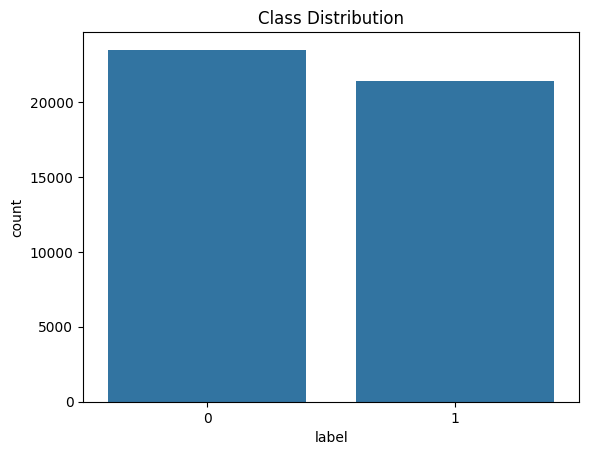

In [12]:
#let's plot it
sns.countplot(x="label", data = df)
plt.title("Class Distribution")
plt.show()

#### Task 1.2 — Prepare the Data

In [13]:
#combine the text and title to improve prediction
df["content"] = df["title"] + " " + df["text"]

In [14]:
# Separate features (X) and label (y)
X = df["content"]
y = df["label"]

In [15]:
# Split into train (80%) and test (20%) sets — use random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

In [16]:
#Stopwords
stop_words = set(stopwords.words("english"))

In [17]:
#Create Cleaning function
def clean(text):
    
    # lowercase
    text = text.lower()
    
    # remove punctuation/numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # remove stopwords
    words = [word for word in text.split() if word not in stop_words]
    
    return " ".join(words)

In [18]:
#Clean
X_train_clean = X_train.apply(clean)
X_test_clean = X_test.apply(clean)

In [19]:
#TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train_clean)

X_test_tfidf = tfidf.transform(X_test_clean)

#### Task 1.3 — Train and Compare Models

In [20]:
#  Train at least 3 models
#I'll use the following three:
# Logistic Regression
lr_model = LogisticRegression()

# Random Forest
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)

# Linear SVM
svm_model = LinearSVC(random_state=RANDOM_STATE)

In [21]:
#Creating an evaluation function
def evaluate_model(name, model, X_train, X_test, y_train, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print results
    print(f"===== {name} =====")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Return results
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

===== Logistic Regression =====
Accuracy: 0.9893
Precision: 0.9863
Recall: 0.9914
F1-score: 0.9888


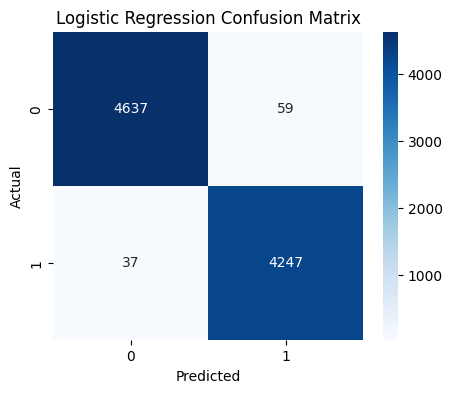

In [22]:
#Now, we evaluate each model

lr_results = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

===== Random Forest =====
Accuracy: 0.9983
Precision: 0.9974
Recall: 0.9991
F1-score: 0.9983


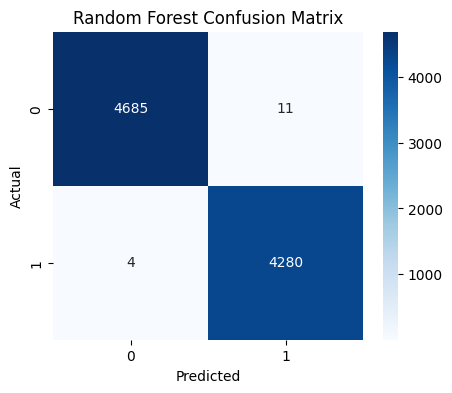

In [23]:
rf_results = evaluate_model(
    "Random Forest",
    rf_model,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

===== Linear SVM =====
Accuracy: 0.9958
Precision: 0.9953
Recall: 0.9958
F1-score: 0.9956


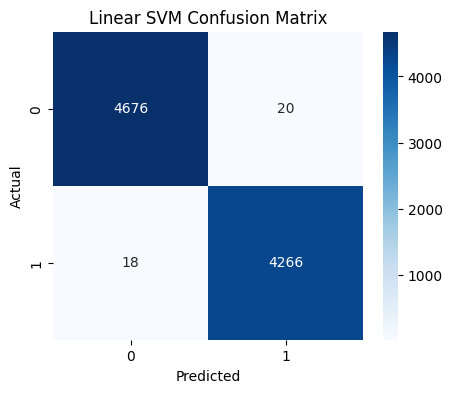

In [24]:
svm_results = evaluate_model(
    "Linear SVM",
    svm_model,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

In [25]:
#Comparison Table
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    svm_results
])

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.989310,0.986298,0.991363,0.988824
1,Random Forest,0.998330,0.997436,0.999066,0.998251
2,Linear SVM,0.995768,0.995334,0.995798,0.995566


In [ ]:
"""Random Forest achieved the best overall performance with the highest accuracy and F1-score. This suggests
that the model was highly effective at distinguishing between fake and real news articles based on textual 
patterns extracted using TF-IDF vectorization. Although Logistic Regression and Linear SVM also performed 
very well, Random Forest produced the most balanced and accurate predictions overall.
The strong performance across all models indicates that fake and real news articles contain highly separable
language patterns."""

#### Task 2.1 — Build and Train

In [26]:
# Convert sparse TF-IDF matrices to dense arrays for Keras
X_train_nn = X_train_tfidf.toarray()
X_test_nn = X_test_tfidf.toarray()

In [ ]:
# Build a neural network using Keras Dense layers with ReLU and Sigmoid/Softmax
# Add at least one Dropout layer to reduce overfitting

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Train for at least 10 epochs
history = model.fit(
    X_train_nn,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9711 - loss: 0.0919 - val_accuracy: 0.9926 - val_loss: 0.0223
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9955 - loss: 0.0142 - val_accuracy: 0.9925 - val_loss: 0.0279
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9987 - loss: 0.0044 - val_accuracy: 0.9915 - val_loss: 0.0324
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9992 - loss: 0.0025 - val_accuracy: 0.9918 - val_loss: 0.0387
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9992 - loss: 0.0023 - val_accuracy: 0.9915 - val_loss: 0.0405
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9921 - val_loss: 0.0407
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9998 - loss: 7.0630e-04 - val_accuracy: 0.9932 - val_loss: 0.0442
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9999 - loss: 4.7275e-04 - val_accu

In [29]:
# Plot the training vs. validation loss and accuracy curves

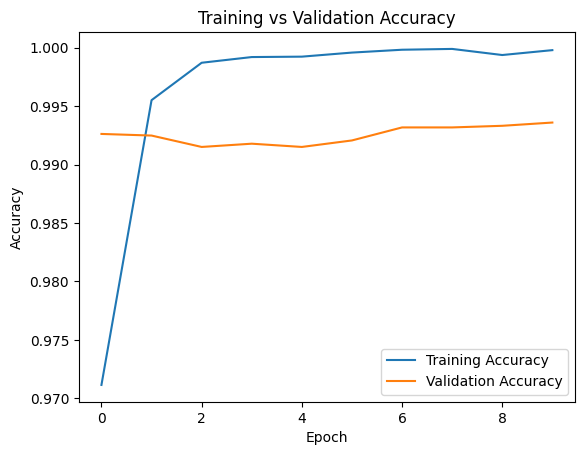

In [30]:
#Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

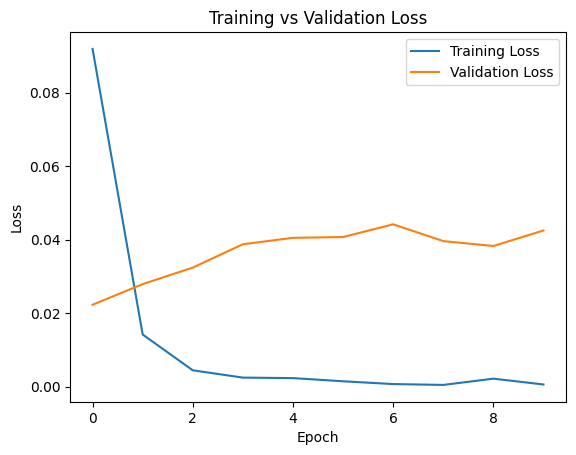

In [31]:
# Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### Task 2.2 — Compare with Step 1

In [32]:
# Predicting using Neural Network
y_pred_nn = model.predict(X_test_nn)

y_pred_nn = (y_pred_nn > 0.5).astype(int)

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [33]:
# Calculate Metrics
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn)
nn_recall = recall_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)

print("Neural Network Results")
print("Accuracy:", nn_accuracy)
print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1-score:", nn_f1)

Neural Network Results
Accuracy: 0.9930957683741648
Precision: 0.9932242990654205
Recall: 0.992296918767507
F1-score: 0.992760392340028


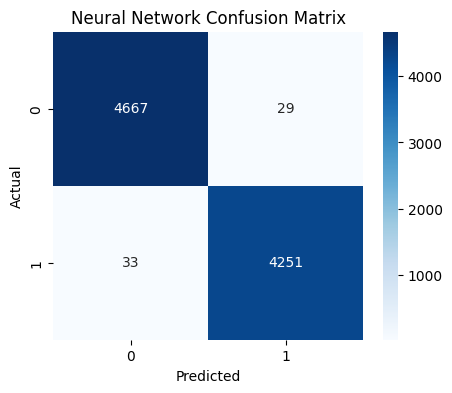

In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
# Now add to the previous Summary Table
nn_results = {
    "Model": "Neural Network",
    "Accuracy": nn_accuracy,
    "Precision": nn_precision,
    "Recall": nn_recall,
    "F1-score": nn_f1
}

In [49]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    svm_results,
    nn_results
])

results_df = results_df.sort_values(
    by="F1-score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-score
1,Random Forest,0.998330,0.997436,0.999066,0.998251
2,Linear SVM,0.995768,0.995334,0.995798,0.995566
3,Neural Network,0.993096,0.993224,0.992297,0.992760
0,Logistic Regression,0.989310,0.986298,0.991363,0.988824


In [ ]:
"""The neural network achieved very high performance with accuracy above 99%, showing that deep learning can
be highly effective for fake news classification. However, Random Forest slightly outperformed the neural 
network in accuracy and F1-score, suggesting that classical machine learning models can still perform 
exceptionally well on TF-IDF text data."""